# **Task 1**

**Importing Libraries**

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

**Applying Smoothing Filters**

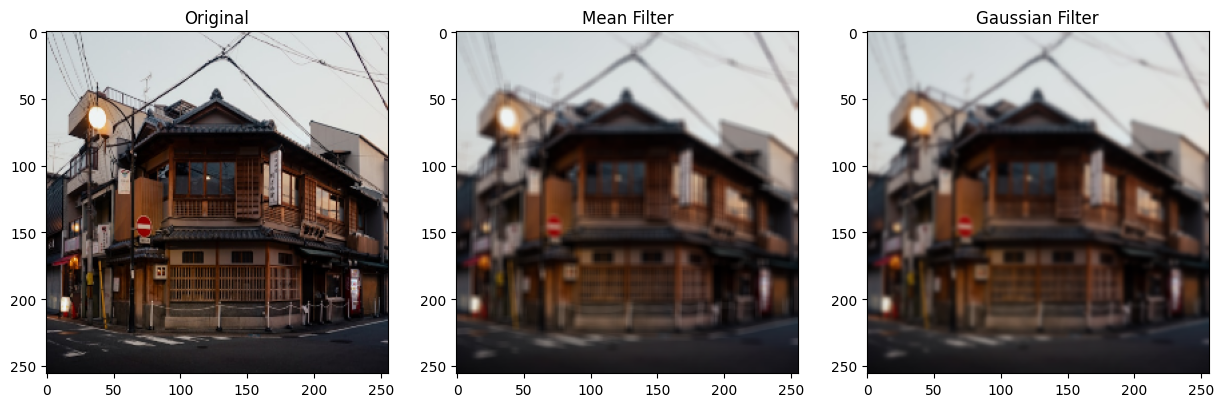

In [ ]:
img=cv2.imread('/content/t1.jpg')
img=cv2.resize(img,(256,256))
mean=cv2.blur(img,(5,5))
gauss=cv2.GaussianBlur(img,(0,0),1.5)
plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))
plt.title('Original')
plt.subplot(1,3,2)
plt.imshow(cv2.cvtColor(mean,cv2.COLOR_BGR2RGB))
plt.title('Mean Filter')
plt.subplot(1,3,3)
plt.imshow(cv2.cvtColor(gauss,cv2.COLOR_BGR2RGB))
plt.title('Gaussian Filter')
plt.show()

**Applying Edge Detection Filters**

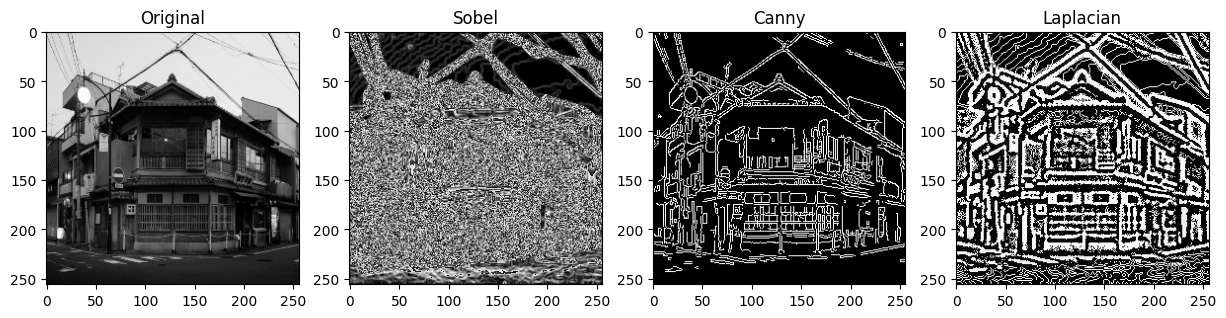

In [ ]:
img=cv2.imread('/content/t1.jpg',0)
img=cv2.resize(img,(256,256))
sx=cv2.Sobel(img,cv2.CV_64F,1,0,ksize=5)
sy=cv2.Sobel(img,cv2.CV_64F,0,1,ksize=5)
sobel=cv2.magnitude(sx,sy).astype(np.uint8)
canny=cv2.Canny(img,100,200)
lap=cv2.Laplacian(cv2.GaussianBlur(img,(0,0),1.5),cv2.CV_64F)
lap=lap.astype(np.uint8)
plt.figure(figsize=(15,5))
plt.subplot(1,4,1)
plt.imshow(img,cmap='gray')
plt.title('Original')
plt.subplot(1,4,2)
plt.imshow(sobel,cmap='gray')
plt.title('Sobel')
plt.subplot(1,4,3)
plt.imshow(canny,cmap='gray')
plt.title('Canny')
plt.subplot(1,4,4)
plt.imshow(lap,cmap='gray')
plt.title('Laplacian')
plt.show()

**Applying Sharpening Filters**

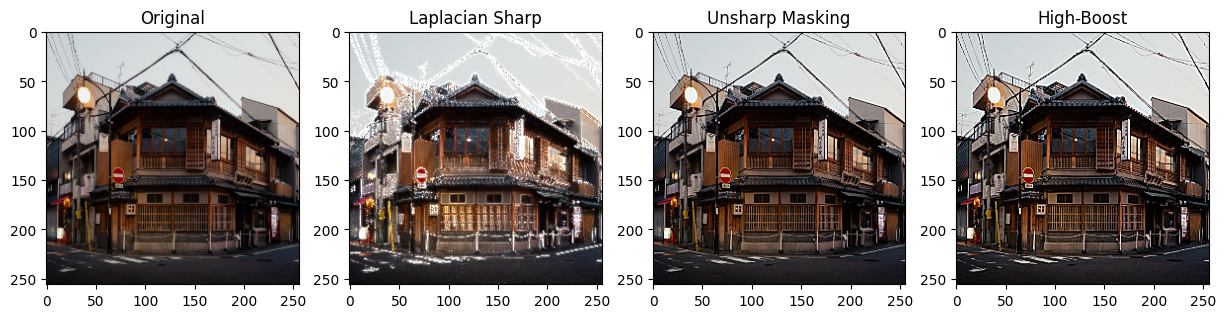

In [ ]:
img=cv2.imread('/content/t1.jpg')
img=cv2.resize(img,(256,256))
lap=cv2.Laplacian(img,cv2.CV_64F)
lap=cv2.convertScaleAbs(lap)
sharp_lap=cv2.add(img,lap)
blur=cv2.GaussianBlur(img,(5,5),0)
sharp_unsharp=cv2.addWeighted(img,2,blur,-1,0)
A=2
sharp_high=cv2.addWeighted(img,A+1,blur,-A,0)
plt.figure(figsize=(15,5))
plt.subplot(1,4,1)
plt.imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))
plt.title('Original')
plt.subplot(1,4,2)
plt.imshow(cv2.cvtColor(sharp_lap,cv2.COLOR_BGR2RGB))
plt.title('Laplacian Sharp')
plt.subplot(1,4,3)
plt.imshow(cv2.cvtColor(sharp_unsharp,cv2.COLOR_BGR2RGB))
plt.title('Unsharp Masking')
plt.subplot(1,4,4)
plt.imshow(cv2.cvtColor(sharp_high,cv2.COLOR_BGR2RGB))
plt.title('High-Boost')
plt.show()

**Applying Border Handling Linear Filtering**

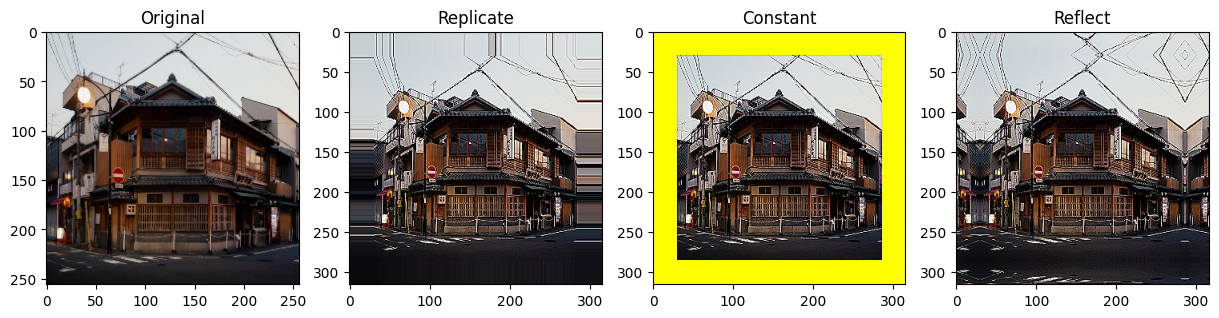

In [ ]:
img=cv2.imread('/content/t1.jpg')
img=cv2.resize(img,(256,256))
kernel=np.array([[0,-1,0],[-1,5,-1],[0,-1,0]],dtype=np.float32)
kernel/=kernel.sum()
const=cv2.copyMakeBorder(img,30,30,30,30,cv2.BORDER_CONSTANT,value=(0,255,255))
rep=cv2.copyMakeBorder(img,30,30,30,30,cv2.BORDER_REPLICATE)
ref=cv2.copyMakeBorder(img,30,30,30,30,cv2.BORDER_REFLECT)
fconst=cv2.filter2D(const,-1,kernel)
frep=cv2.filter2D(rep,-1,kernel)
fref=cv2.filter2D(ref,-1,kernel)
plt.figure(figsize=(15,5))
plt.subplot(1,4,1)
plt.imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))
plt.title('Original')
plt.subplot(1,4,2)
plt.imshow(cv2.cvtColor(frep,cv2.COLOR_BGR2RGB))
plt.title('Replicate')
plt.subplot(1,4,3)
plt.imshow(cv2.cvtColor(fconst,cv2.COLOR_BGR2RGB))
plt.title('Constant')
plt.subplot(1,4,4)
plt.imshow(cv2.cvtColor(fref,cv2.COLOR_BGR2RGB))
plt.title('Reflect')
plt.show()

**Apply Non Linear Filtering**

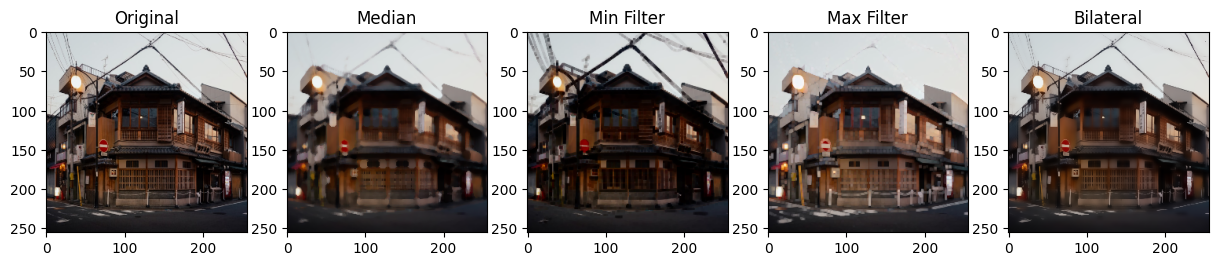

In [ ]:
img=cv2.imread('/content/t1.jpg')
img=cv2.resize(img,(256,256))
median=cv2.medianBlur(img,5)
kernel=cv2.getStructuringElement(cv2.MORPH_RECT,(3,3))
minf=cv2.erode(img,kernel)
maxf=cv2.dilate(img,kernel)
bilat=cv2.bilateralFilter(img,9,75,75)
plt.figure(figsize=(15,5))
plt.subplot(1,5,1)
plt.imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))
plt.title('Original')
plt.subplot(1,5,2)
plt.imshow(cv2.cvtColor(median,cv2.COLOR_BGR2RGB))
plt.title('Median')
plt.subplot(1,5,3)
plt.imshow(cv2.cvtColor(minf,cv2.COLOR_BGR2RGB))
plt.title('Min Filter')
plt.subplot(1,5,4)
plt.imshow(cv2.cvtColor(maxf,cv2.COLOR_BGR2RGB))
plt.title('Max Filter')
plt.subplot(1,5,5)
plt.imshow(cv2.cvtColor(bilat,cv2.COLOR_BGR2RGB))
plt.title('Bilateral')
plt.show()

**Doing 1D Sampling**

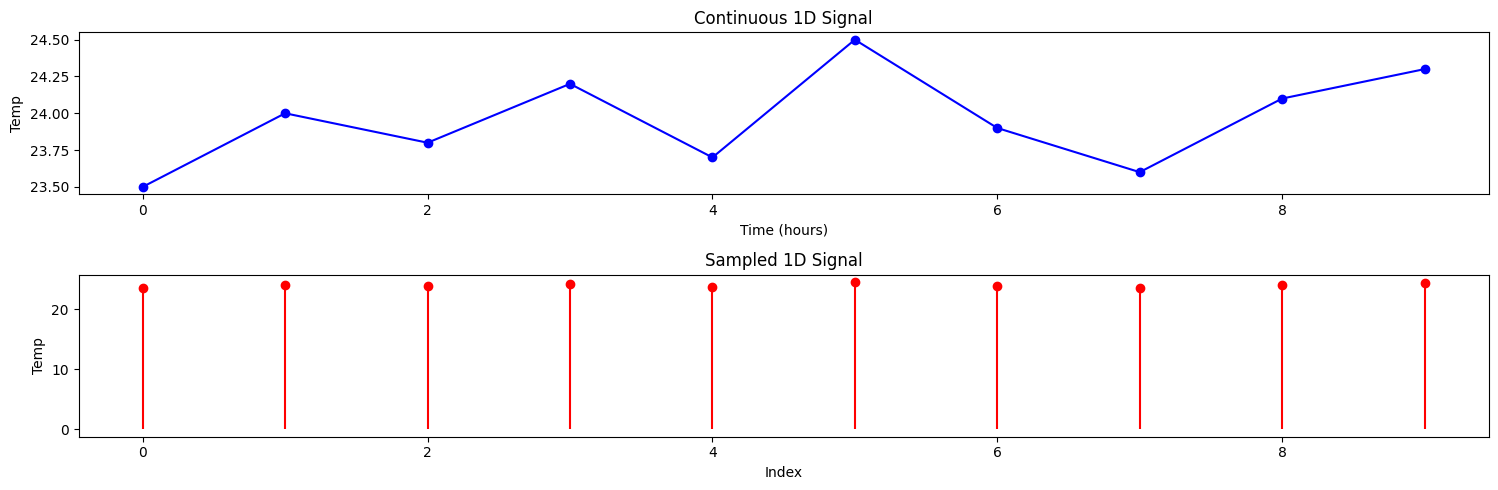

In [ ]:
sig=np.array([23.5,24.0,23.8,24.2,23.7,24.5,23.9,23.6,24.1,24.3])
idx=np.arange(0,len(sig))
plt.figure(figsize=(15,5))
plt.subplot(2,1,1)
plt.plot(idx,sig,marker='o',color='b')
plt.title('Continuous 1D Signal')
plt.xlabel('Time (hours)')
plt.ylabel('Temp')
plt.subplot(2,1,2)
plt.stem(idx,sig,basefmt=" ",markerfmt="ro",linefmt="-r")
plt.title('Sampled 1D Signal')
plt.xlabel('Index')
plt.ylabel('Temp')
plt.tight_layout()
plt.show()

**Doing 2D Sampling**

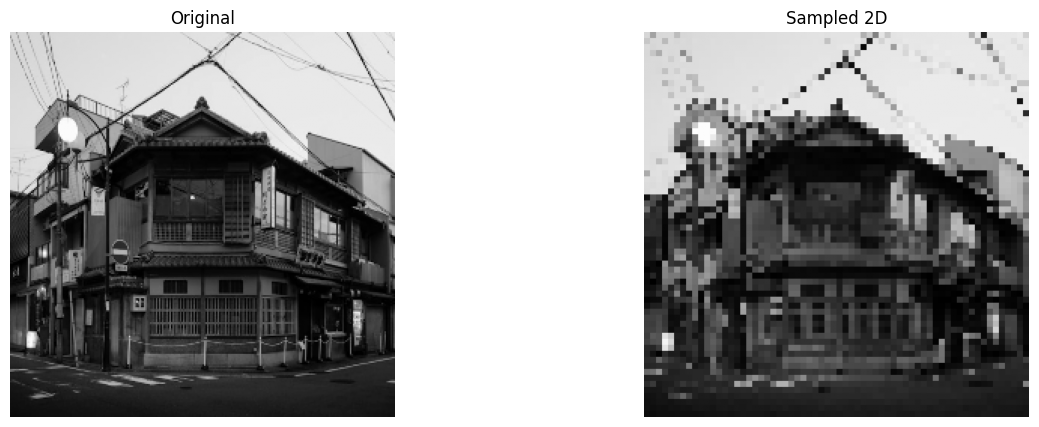

In [ ]:
img=cv2.imread('/content/t1.jpg',0)
img=cv2.resize(img,(256,256))
down=img[::4,::4]
up=cv2.resize(down,(img.shape[1],img.shape[0]),interpolation=cv2.INTER_NEAREST)
plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
plt.imshow(img,cmap='gray')
plt.title('Original')
plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(up,cmap='gray')
plt.title('Sampled 2D')
plt.axis('off')
plt.show()

# **Task 2**

**Importing Libraries**

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

**Applying Gaussian Blur**

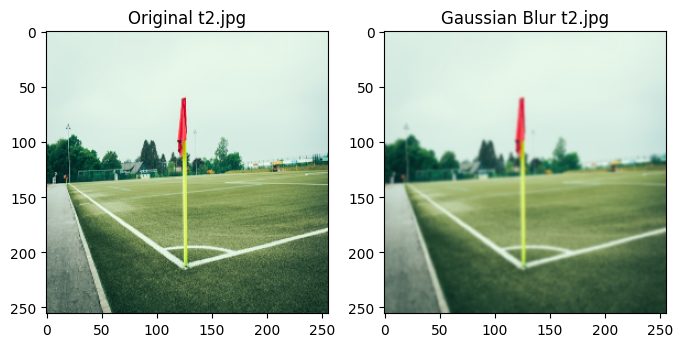

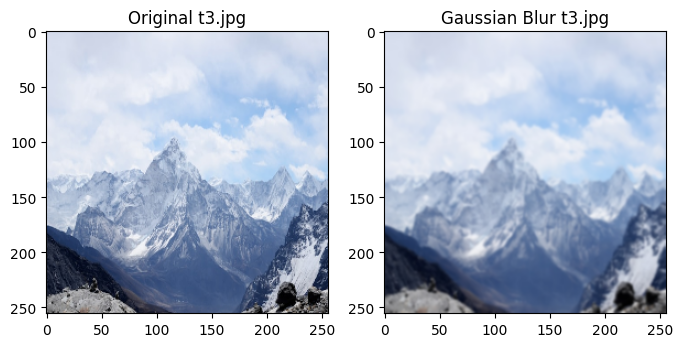

In [ ]:
for f in ['t2.jpg','t3.jpg']:
    img=cv2.imread('/content/'+f)
    img=cv2.resize(img,(256,256))
    g=cv2.GaussianBlur(img,(5,5),0)
    plt.figure(figsize=(8,4))
    plt.subplot(1,2,1)
    plt.imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))
    plt.title('Original '+f)
    plt.subplot(1,2,2)
    plt.imshow(cv2.cvtColor(g,cv2.COLOR_BGR2RGB))
    plt.title('Gaussian Blur '+f)
    plt.show()

**Applying Sobel Filter For Edge Detection**

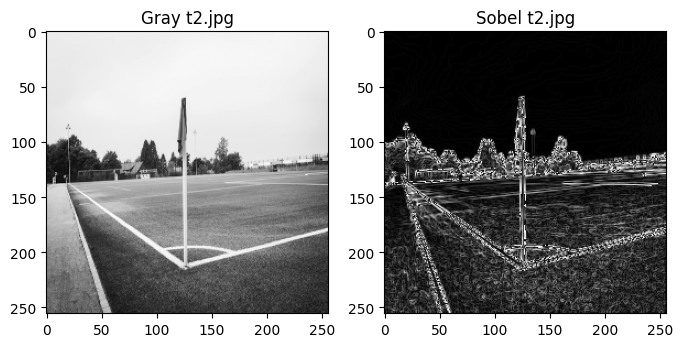

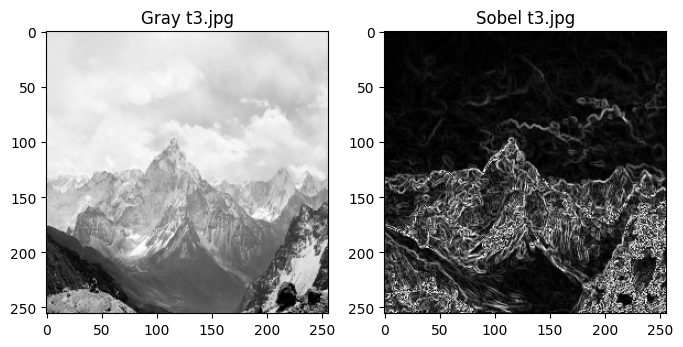

In [ ]:
for f in ['t2.jpg','t3.jpg']:
    img=cv2.imread('/content/'+f,0)
    img=cv2.resize(img,(256,256))
    sx=cv2.Sobel(img,cv2.CV_64F,1,0,5)
    sy=cv2.Sobel(img,cv2.CV_64F,0,1,5)
    s=cv2.magnitude(sx,sy).astype(np.uint8)
    plt.figure(figsize=(8,4))
    plt.subplot(1,2,1)
    plt.imshow(img,cmap='gray')
    plt.title('Gray '+f)
    plt.subplot(1,2,2)
    plt.imshow(s,cmap='gray')
    plt.title('Sobel '+f)
    plt.show()

**Applying Laplacian Filter For Image Sharpening**

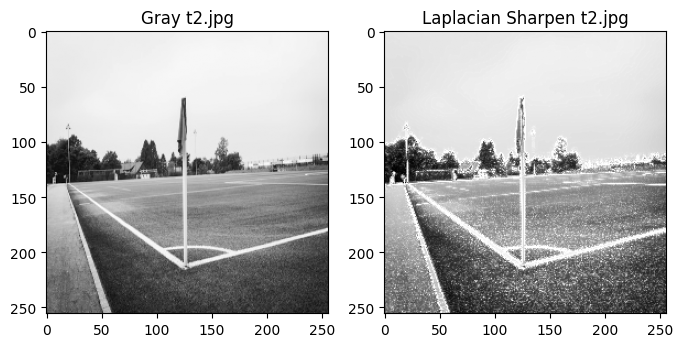

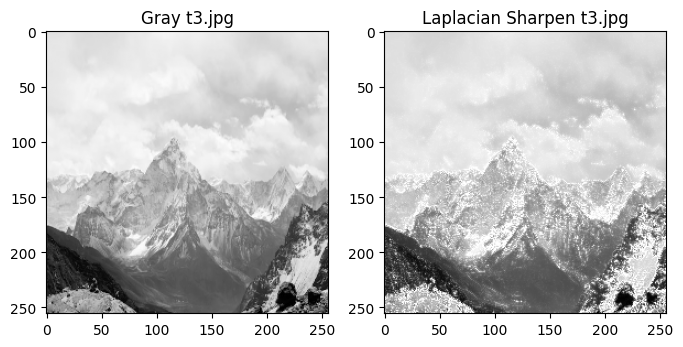

In [ ]:
for f in ['t2.jpg','t3.jpg']:
    img=cv2.imread('/content/'+f,0)
    img=cv2.resize(img,(256,256))
    l=cv2.Laplacian(img,cv2.CV_64F)
    l=np.uint8(np.absolute(l))
    sh=cv2.add(img,l)
    plt.figure(figsize=(8,4))
    plt.subplot(1,2,1)
    plt.imshow(img,cmap='gray')
    plt.title('Gray '+f)
    plt.subplot(1,2,2)
    plt.imshow(sh,cmap='gray')
    plt.title('Laplacian Sharpen '+f)
    plt.show()

**Applying Mean Filter for Noise Reduction**

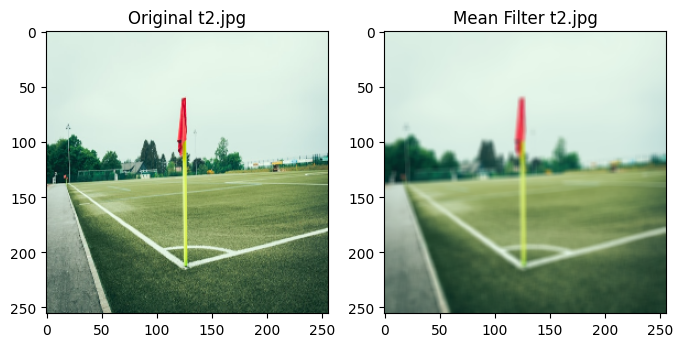

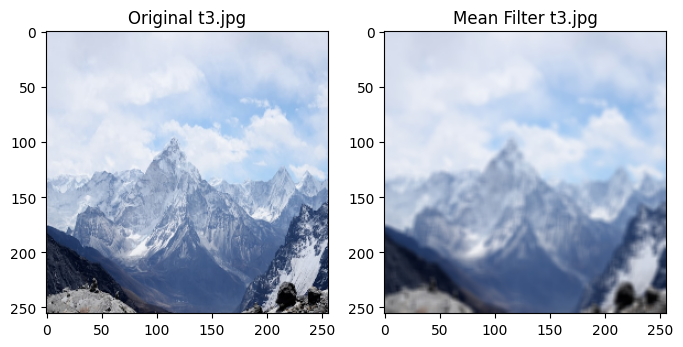

In [ ]:
for f in ['t2.jpg','t3.jpg']:
    img=cv2.imread('/content/'+f)
    img=cv2.resize(img,(256,256))
    m=cv2.blur(img,(5,5))
    plt.figure(figsize=(8,4))
    plt.subplot(1,2,1)
    plt.imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))
    plt.title('Original '+f)
    plt.subplot(1,2,2)
    plt.imshow(cv2.cvtColor(m,cv2.COLOR_BGR2RGB))
    plt.title('Mean Filter '+f)
    plt.show()

# **Task 3**

**Importing Libraries**

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

**Applying Median Filter**

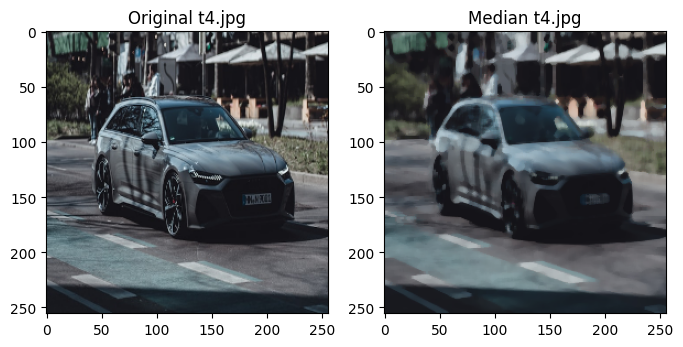

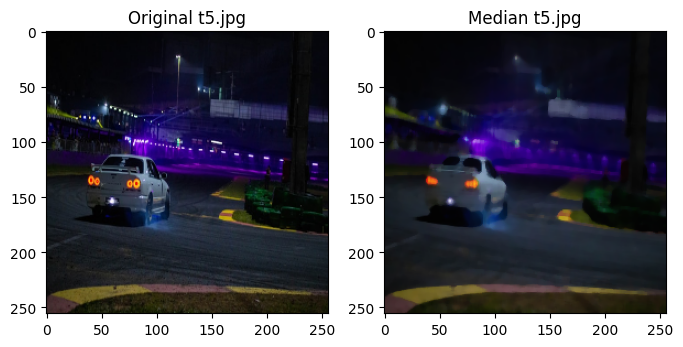

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
for f in ['t4.jpg','t5.jpg']:
    img=cv2.imread('/content/'+f)
    img=cv2.resize(img,(256,256))
    med=cv2.medianBlur(img,5)
    plt.figure(figsize=(8,4))
    plt.subplot(1,2,1)
    plt.imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))
    plt.title('Original '+f)
    plt.subplot(1,2,2)
    plt.imshow(cv2.cvtColor(med,cv2.COLOR_BGR2RGB))
    plt.title('Median '+f)
    plt.show()

**Applying Max Filter To Perform Dilation**

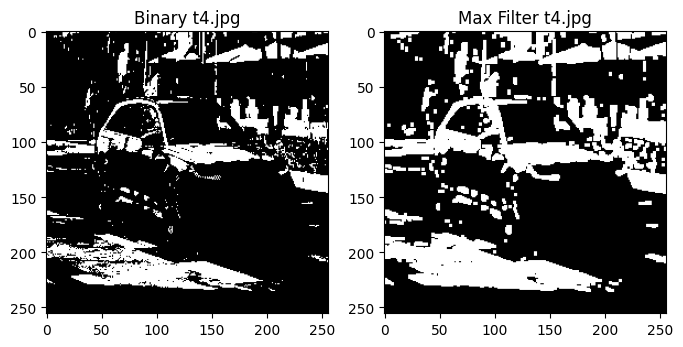

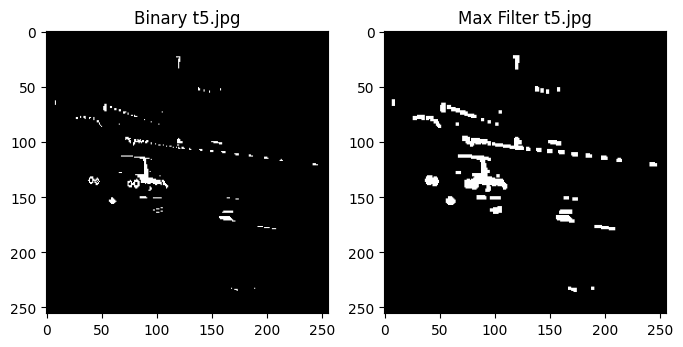

In [ ]:
for f in ['t4.jpg','t5.jpg']:
    img=cv2.imread('/content/'+f,0)
    img=cv2.resize(img,(256,256))
    _,bin=cv2.threshold(img,127,255,cv2.THRESH_BINARY)
    k=cv2.getStructuringElement(cv2.MORPH_RECT,(3,3))
    d=cv2.dilate(bin,k)
    plt.figure(figsize=(8,4))
    plt.subplot(1,2,1)
    plt.imshow(bin,cmap='gray')
    plt.title('Binary '+f)
    plt.subplot(1,2,2)
    plt.imshow(d,cmap='gray')
    plt.title('Max Filter '+f)
    plt.show()

**Applying Min Filter To Perform Erosion**

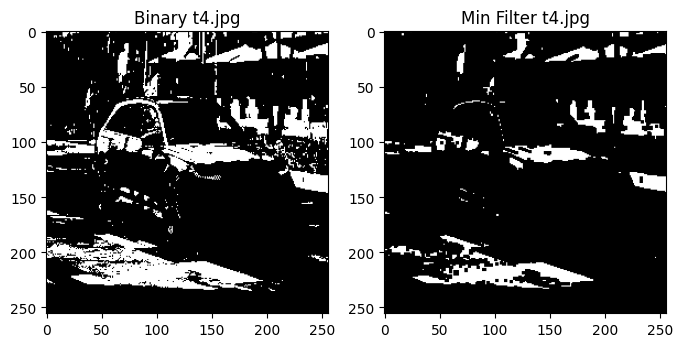

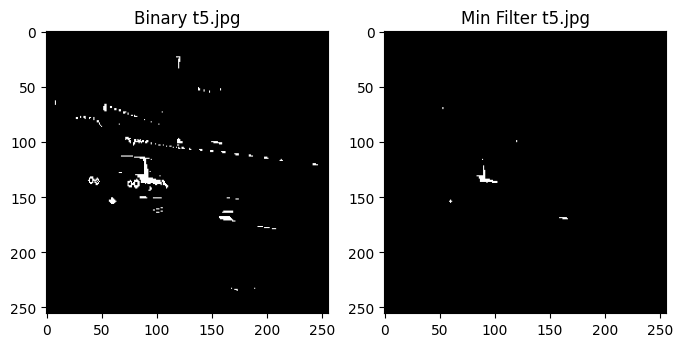

In [ ]:
for f in ['t4.jpg','t5.jpg']:
    img=cv2.imread('/content/'+f,0)
    img=cv2.resize(img,(256,256))
    _,bin=cv2.threshold(img,127,255,cv2.THRESH_BINARY)
    k=cv2.getStructuringElement(cv2.MORPH_RECT,(3,3))
    e=cv2.erode(bin,k)
    plt.figure(figsize=(8,4))
    plt.subplot(1,2,1)
    plt.imshow(bin,cmap='gray')
    plt.title('Binary '+f)
    plt.subplot(1,2,2)
    plt.imshow(e,cmap='gray')
    plt.title('Min Filter '+f)
    plt.show()

**Creating A Bilateral Filter For Edge Preserving Smoothing**

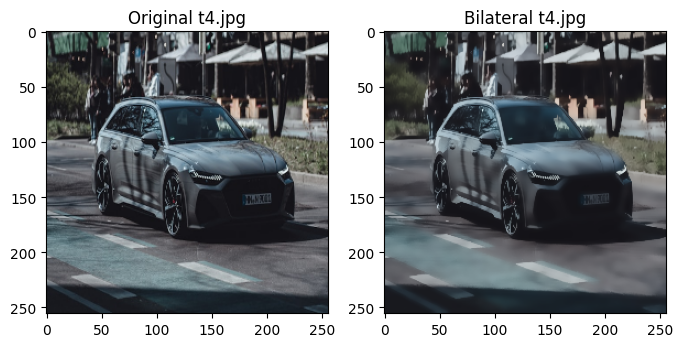

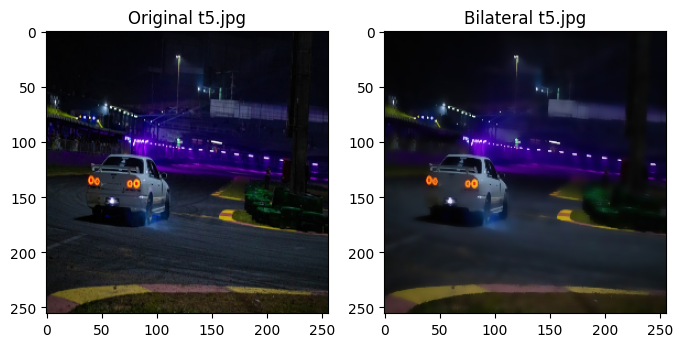

In [ ]:
for f in ['t4.jpg','t5.jpg']:
    img=cv2.imread('/content/'+f)
    img=cv2.resize(img,(256,256))
    b=cv2.bilateralFilter(img,9,75,75)
    plt.figure(figsize=(8,4))
    plt.subplot(1,2,1)
    plt.imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))
    plt.title('Original '+f)
    plt.subplot(1,2,2)
    plt.imshow(cv2.cvtColor(b,cv2.COLOR_BGR2RGB))
    plt.title('Bilateral '+f)
    plt.show()

**Implementing An Adaptive Median Filter For Noise Reduction**

In [ ]:
def admed(img,smax=15):
    r,c=img.shape
    out=img.copy()
    for i in range(r):
        for j in range(c):
            s=3
            while s<=smax:
                x1,y1=max(i-s//2,0),max(j-s//2,0)
                x2,y2=min(i+s//2,r-1),min(j+s//2,c-1)
                win=img[x1:x2+1,y1:y2+1]
                zmin,zmax,zmed=np.min(win),np.max(win),np.median(win)
                if zmin<zmed<zmax:
                    out[i,j]=img[i,j] if zmin<img[i,j]<zmax else zmed
                    break
                s+=2
            else:
                out[i,j]=zmed
    return out.astype(np.uint8)

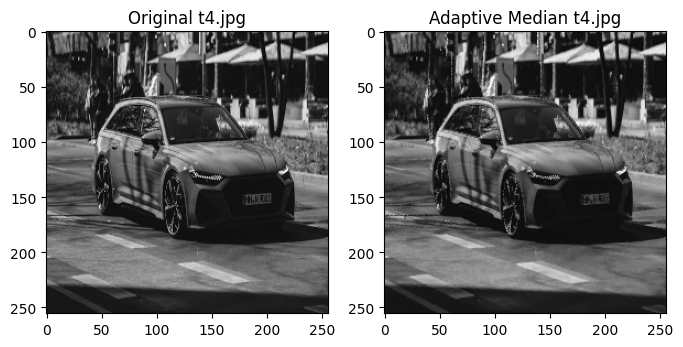

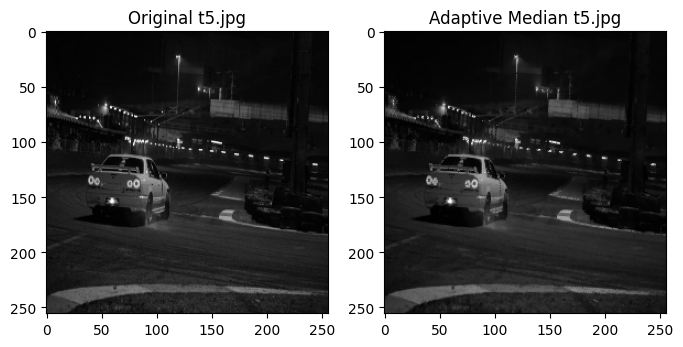

In [ ]:
for f in ['t4.jpg','t5.jpg']:
    img=cv2.imread('/content/'+f,0)
    img=cv2.resize(img,(256,256))
    ad=admed(img)
    plt.figure(figsize=(8,4))
    plt.subplot(1,2,1)
    plt.imshow(img,cmap='gray')
    plt.title('Original '+f)
    plt.subplot(1,2,2)
    plt.imshow(ad,cmap='gray')
    plt.title('Adaptive Median '+f)
    plt.show()